# ANALISIS DE SENTIMIENTOS 

## Entre 1 y 2 minutos de carga (TOTAL DE REVIEWS)

In [6]:
import pandas as pd
import glob
import os

# Ruta a la carpeta donde están los archivos CSV
carpeta_reviews = os.path.join(os.getcwd(), 'Datos Limpios', 'reviews')

# Usar glob para obtener la lista de archivos CSV
archivos_csv = glob.glob(os.path.join(carpeta_reviews, '*.csv'))  # Asegúrate de buscar archivos .csv

# Cargar todos los archivos CSV en un DataFrame
dataframes = []
for archivo in archivos_csv:
    df = pd.read_csv(archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
reviews = pd.concat(dataframes, ignore_index=True)

In [7]:
reviews

,user_id,name,time,rating,text,gmap_id,Estado
0,1.179759e+20,Anthony Roberts,2016-05-16 23:56:53.514,4,"On the higher end of price for pizza, but they...",0x8889221157fb3455:0x5c125c40c3eccc2a,AL
1,1.143165e+20,Jonathan Robert,2015-11-15 21:45:39.865,3,"Food was ok, felt like the atmosphere as well ...",0x8889221157fb3455:0x5c125c40c3eccc2a,AL
2,1.136326e+20,Brian Harvey,2016-07-23 17:05:49.247,4,"Good food, service so so",0x8889221157fb3455:0x5c125c40c3eccc2a,AL
3,1.076840e+20,Ashley Maddox,2015-09-15 01:06:59.480,5,Love it,0x8889221157fb3455:0x5c125c40c3eccc2a,AL
4,1.126036e+20,West Martin,2013-10-24 17:14:56.130,5,Yum,0x8889221157fb3455:0x5c125c40c3eccc2a,AL
...,...,...,...,...,...,...,...
12392918,1.066896e+20,Nancy Schaffer,2017-11-30 02:54:03.190,5,NaN,0x5335fac0b65b4243:0x78f735c40c344b01,WY
12392919,1.019377e+20,Mackenzie Mayer,2018-06-30 01:26:11.461,2,NaN,0x5335fac0b65b4243:0x78f735c40c344b01,WY
12392920,1.087467e+20,Walter Orum,2017-04-05 14:12:00.613,5,NaN,0x5335fac0b65b4243:0x78f735c40c344b01,WY
12392921,1.124218e+20,Charissa Carver,2019-04-25 21:51:31.462,5,NaN,0x5335fac0b65b4243:0x78f735c40c344b01,WY


El analisis de sentimiento se basará en el texto

In [8]:
reviews["text"].isnull().value_counts()

text
False    7155487
True     5237436
Name: count, dtype: int64

Las reseñas que no tienen texto (solo valoración) no serán consideradas. En primer instancia.

In [9]:
reviews.dropna(subset=['text'], inplace=True)

In [13]:
reviews["gmap_id"].nunique()

145131

145,131 restaurantes con reseñas en texto.

In [14]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7155487 entries, 0 to 12392797
Data columns (total 7 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  float64
 1   name     object 
 2   time     object 
 3   rating   int64  
 4   text     object 
 5   gmap_id  object 
 6   Estado   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 436.7+ MB


Preprocesamiento

In [15]:
import nltk
from nltk.corpus import stopwords
import string

# Descargar stopwords si no lo has hecho
nltk.download('stopwords')

stop_words = set(stopwords.words('spanish'))  # Cambia a 'english' si tus textos están en inglés

def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar puntuaciones
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Eliminar stop words
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Aplicar la función de limpieza
reviews['cleaned_text'] = reviews['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aleja\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


2 minutos

Analisis de Sentimientos

32 minutos

In [16]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    # Retornar el sentimiento como positivo, negativo o neutral
    if analysis.sentiment.polarity > 0:
        return 'positivo'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negativo'

# Aplicar la función de análisis de sentimiento
reviews['sentiment'] = reviews['cleaned_text'].apply(get_sentiment)

Visualización

sentiment
positivo    6021820
negativo     690301
neutral      443366
Name: count, dtype: int64


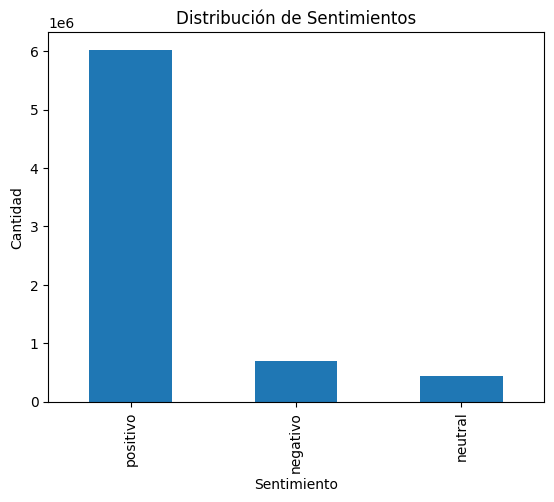

In [17]:
# Contar la cantidad de cada tipo de sentimiento
sentiment_counts = reviews['sentiment'].value_counts()
print(sentiment_counts)

# Visualización (opcional, requiere matplotlib o seaborn)
import matplotlib.pyplot as plt

sentiment_counts.plot(kind='bar')
plt.title('Distribución de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.show()

In [18]:
reviews

,user_id,name,time,rating,text,gmap_id,Estado,cleaned_text,sentiment
0,1.179759e+20,Anthony Roberts,2016-05-16 23:56:53.514,4,"On the higher end of price for pizza, but they...",0x8889221157fb3455:0x5c125c40c3eccc2a,AL,on the higher end of price for pizza but they ...,positivo
1,1.143165e+20,Jonathan Robert,2015-11-15 21:45:39.865,3,"Food was ok, felt like the atmosphere as well ...",0x8889221157fb3455:0x5c125c40c3eccc2a,AL,food was ok felt like the atmosphere as well a...,positivo
2,1.136326e+20,Brian Harvey,2016-07-23 17:05:49.247,4,"Good food, service so so",0x8889221157fb3455:0x5c125c40c3eccc2a,AL,good food service so so,positivo
3,1.076840e+20,Ashley Maddox,2015-09-15 01:06:59.480,5,Love it,0x8889221157fb3455:0x5c125c40c3eccc2a,AL,love it,positivo
4,1.126036e+20,West Martin,2013-10-24 17:14:56.130,5,Yum,0x8889221157fb3455:0x5c125c40c3eccc2a,AL,yum,neutral
...,...,...,...,...,...,...,...,...,...
12392793,1.050981e+20,Jake Burridge,2017-09-08 11:32:50.161,5,Great Spot,0x5335fac0b65b4243:0x78f735c40c344b01,WY,great spot,positivo
12392794,1.049398e+20,Luke Wicht,2018-01-12 22:20:33.541,4,"Good food, slow sometimes",0x5335fac0b65b4243:0x78f735c40c344b01,WY,good food slow sometimes,positivo
12392795,1.159338e+20,Jody Kobielusz,2016-11-08 02:02:21.300,5,Excellent food and ice cream.,0x5335fac0b65b4243:0x78f735c40c344b01,WY,excellent food and ice cream,positivo
12392796,1.039343e+20,Schoeny Builders,2016-12-24 04:03:28.426,3,I love blizzards but I wish they put more topp...,0x5335fac0b65b4243:0x78f735c40c344b01,WY,i love blizzards but i wish they put more topp...,positivo


Primer guarda de datos, 1.2 GB en  20 segundos

In [24]:
reviews.to_parquet("Sentimientosv1.parquet",index = False)

In [37]:
reviews = reviews[["gmap_id","Estado","time","rating","cleaned_text","sentiment"]]

563 MB en 10 segundos, es la que va

In [38]:
reviews.to_parquet("Sentimientosv2.parquet",index = False)

20 segundos para lectura y carga

In [36]:
reviews = pd.read_parquet("Sentimientosv1.parquet")

In [39]:
reviews = pd.read_parquet("Sentimientosv2.parquet")

In [45]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7155487 entries, 0 to 7155486
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   gmap_id       object
 1   Estado        object
 2   time          object
 3   rating        int64 
 4   cleaned_text  object
 5   sentiment     object
dtypes: int64(1), object(5)
memory usage: 327.6+ MB


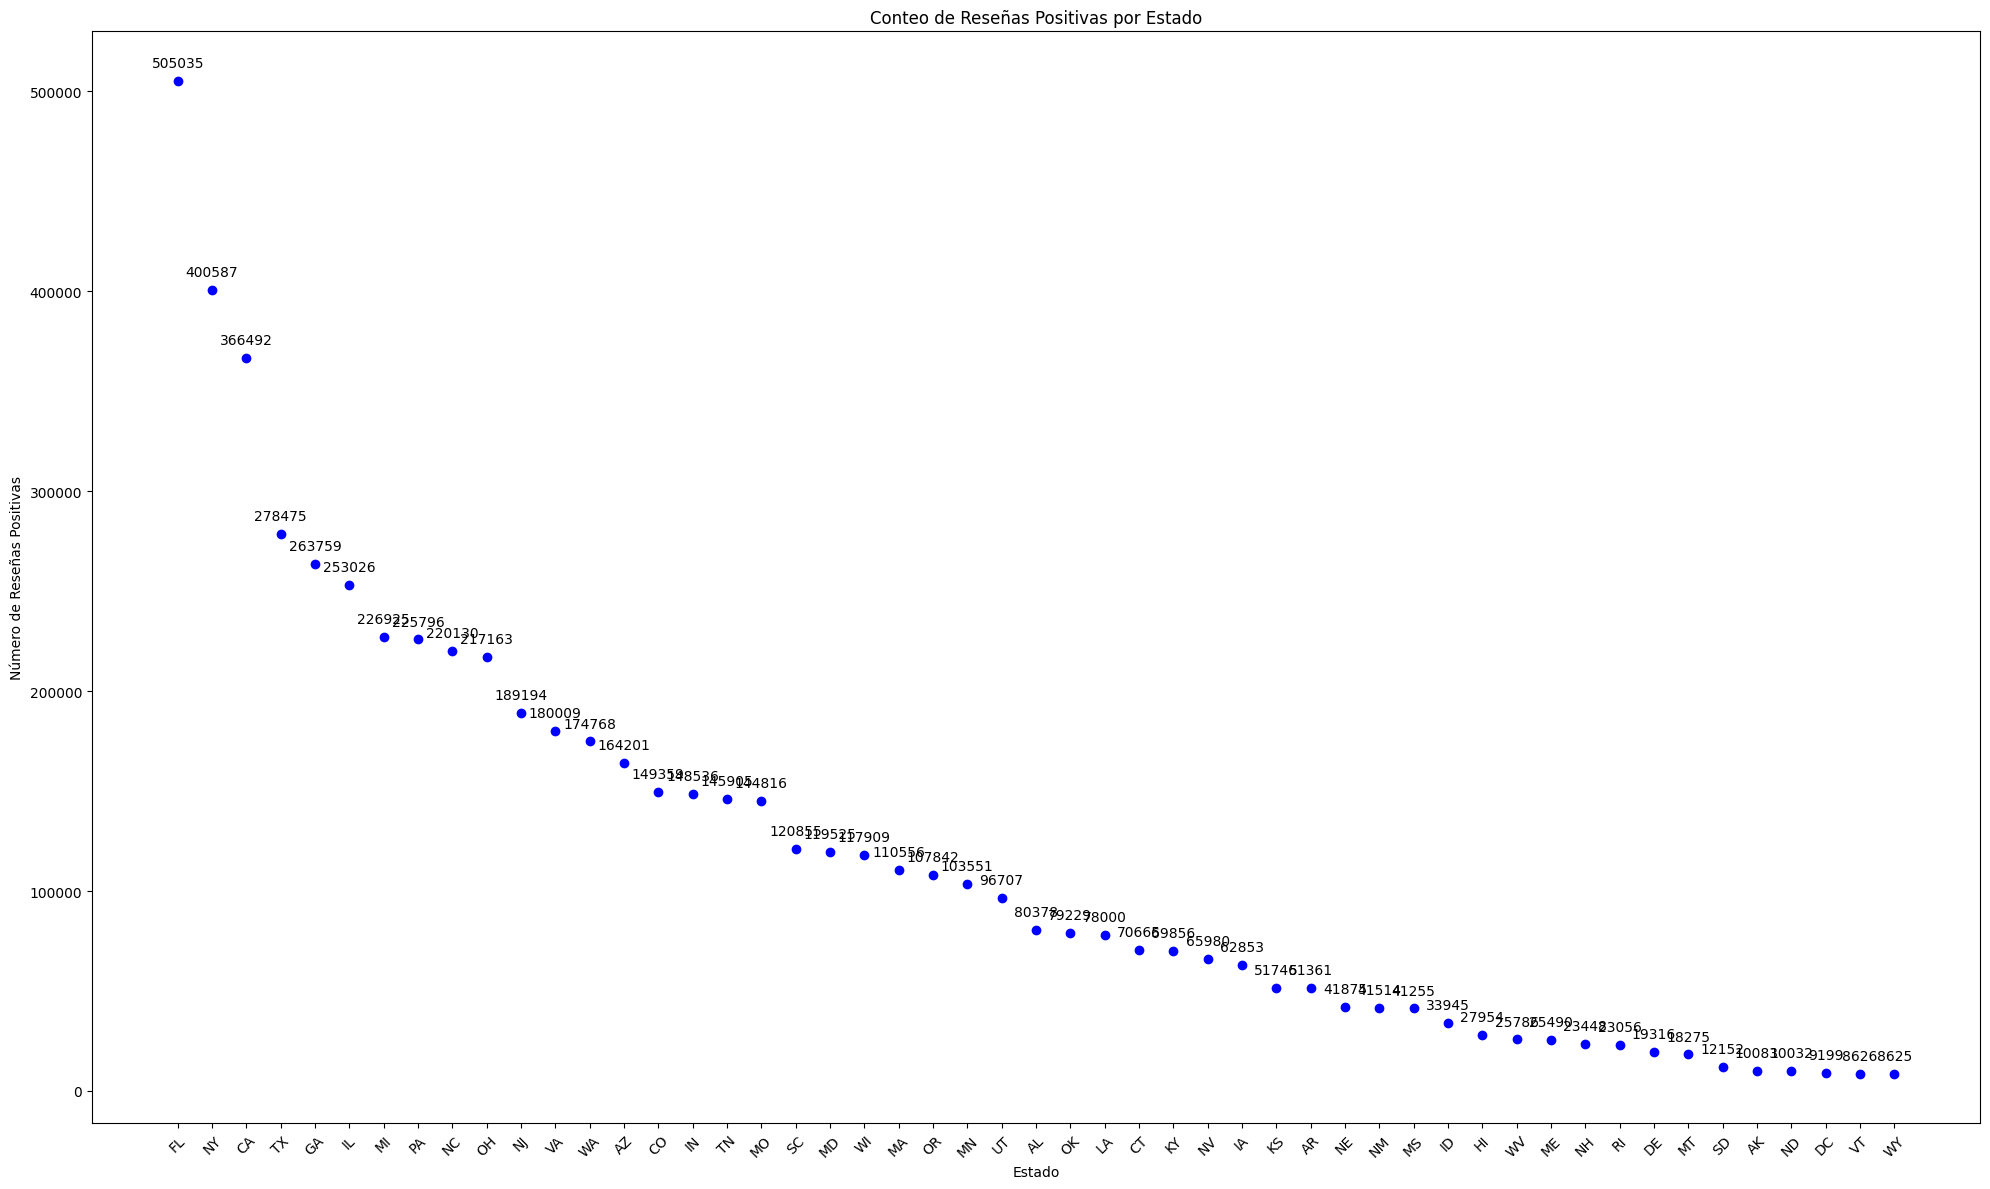

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Suponiendo que tienes tu DataFrame en una variable llamada `df`
# Filtrar las reseñas con sentimiento positivo
df_positivo = reviews[reviews['sentiment'] == 'positivo']

# Contar la cantidad de reseñas positivas por estado
conteo_por_estado = df_positivo['Estado'].value_counts()

# Crear el gráfico de puntos
plt.figure(figsize=(20, 12))
plt.scatter(conteo_por_estado.index, conteo_por_estado.values, color='blue')

# Añadir etiquetas y título
plt.title('Conteo de Reseñas Positivas por Estado')
plt.xlabel('Estado')
plt.ylabel('Número de Reseñas Positivas')

# Mostrar los valores en los puntos
for i, txt in enumerate(conteo_por_estado.values):
    plt.annotate(txt, (conteo_por_estado.index[i], conteo_por_estado.values[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


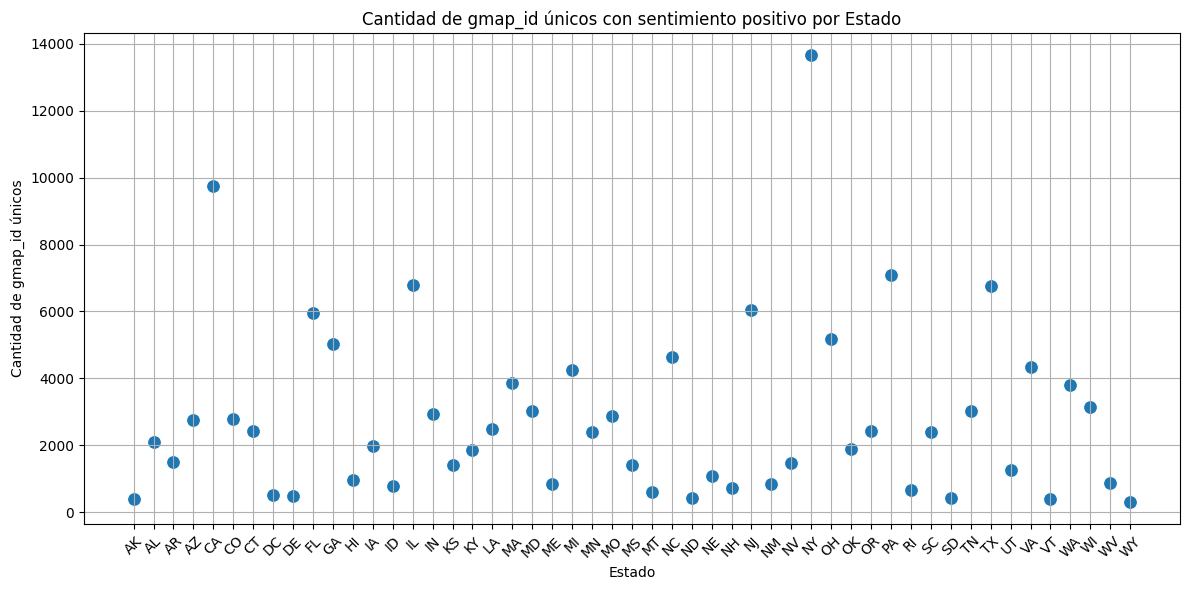

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar tus datos en un DataFrame (asumiendo que ya está en 'reviews')
# reviews = pd.read_csv('tu_archivo.csv')  # Descomentar esto si necesitas cargar un archivo CSV

# Filtrar el DataFrame para obtener solo los sentimientos positivos
positive_reviews = reviews[reviews['sentiment'] == 'positivo']

# Agrupar por 'Estado' y contar la cantidad de gmap_id únicos
grouped = positive_reviews.groupby('Estado')['gmap_id'].nunique().reset_index()

# Renombrar la columna para mayor claridad
grouped.columns = ['Estado', 'Cantidad_unicos']

# Crear el gráfico de puntos
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped, x='Estado', y='Cantidad_unicos', s=100)

# Añadir etiquetas y título
plt.title('Cantidad de gmap_id únicos con sentimiento positivo por Estado')
plt.xlabel('Estado')
plt.ylabel('Cantidad de gmap_id únicos')
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.grid()

# Mostrar el gráfico
plt.tight_layout()
plt.show()


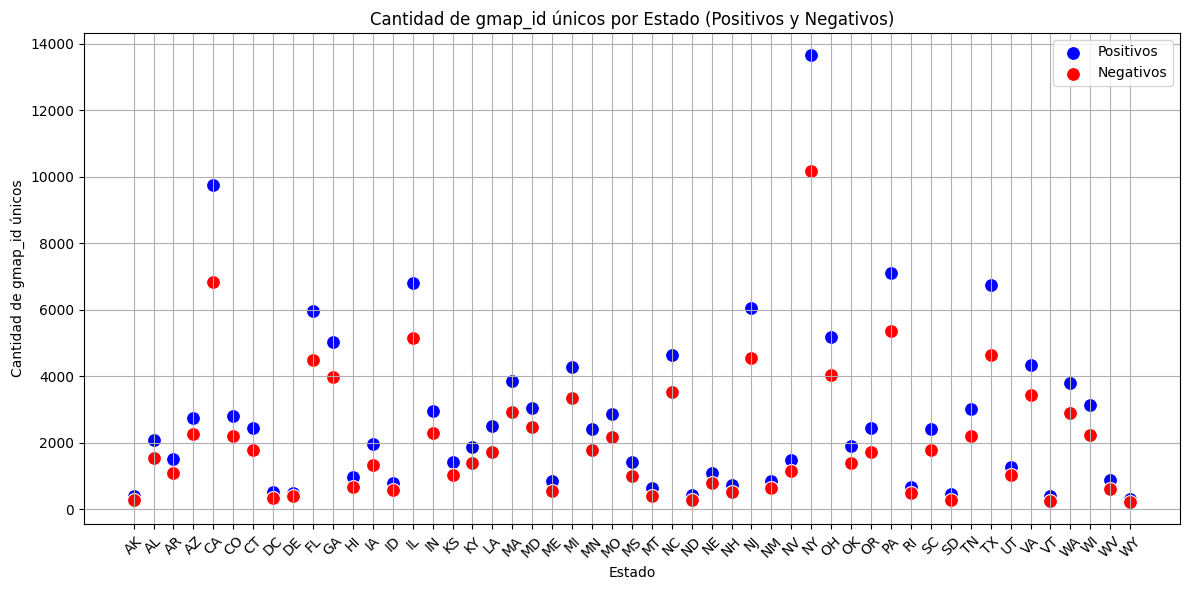

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar tus datos en un DataFrame (asumiendo que ya está en 'reviews')
# reviews = pd.read_csv('tu_archivo.csv')  # Descomentar esto si necesitas cargar un archivo CSV

# Filtrar el DataFrame para obtener solo los sentimientos positivos y negativos
positive_reviews = reviews[reviews['sentiment'] == 'positivo']
negative_reviews = reviews[reviews['sentiment'] == 'negativo']

# Agrupar por 'Estado' y contar la cantidad de gmap_id únicos
grouped_positive = positive_reviews.groupby('Estado')['gmap_id'].nunique().reset_index()
grouped_negative = negative_reviews.groupby('Estado')['gmap_id'].nunique().reset_index()

# Renombrar las columnas para mayor claridad
grouped_positive.columns = ['Estado', 'Cantidad_unicos_positivos']
grouped_negative.columns = ['Estado', 'Cantidad_unicos_negativos']

# Fusionar DataFrames positivos y negativos
merged = pd.merge(grouped_positive, grouped_negative, on='Estado', how='outer').fillna(0)

# Crear el gráfico de puntos
plt.figure(figsize=(12, 6))

# Graficar los positivos
sns.scatterplot(data=merged, x='Estado', y='Cantidad_unicos_positivos', s=100, color='blue', label='Positivos')

# Graficar los negativos
sns.scatterplot(data=merged, x='Estado', y='Cantidad_unicos_negativos', s=100, color='red', label='Negativos')

# Añadir etiquetas y título
plt.title('Cantidad de gmap_id únicos por Estado (Positivos y Negativos)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de gmap_id únicos')
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.grid()
plt.legend()  # Añadir leyenda para distinguir colores

# Mostrar el gráfico
plt.tight_layout()
plt.show()


Correlación Rating- Sentimiento

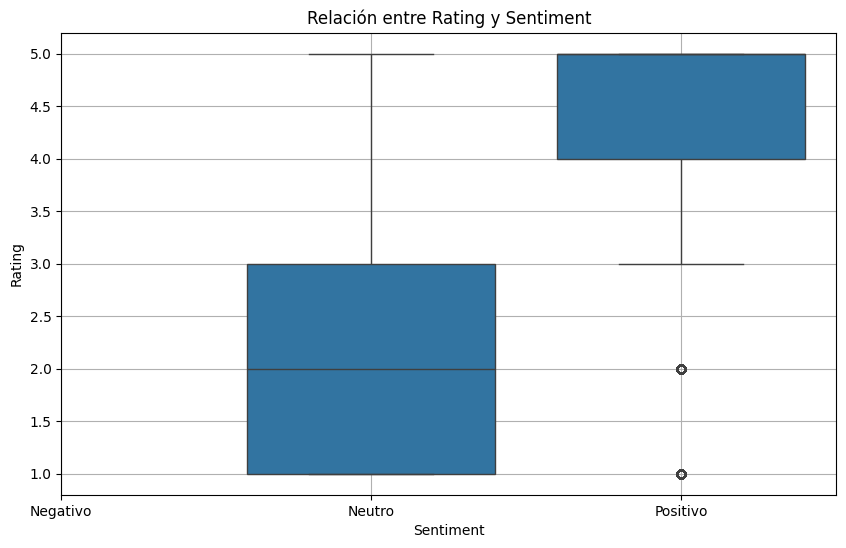

In [46]:
# Convertir la columna sentiment a valores numéricos
sentiment_mapping = {
    'positivo': 1,
    'neutro': 0,
    'negativo': -1
}

reviews['sentiment_numeric'] = reviews['sentiment'].map(sentiment_mapping)

# Ahora, puedes graficar la relación usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment_numeric', y='rating', data=reviews)
plt.xticks(ticks=[-1, 0, 1], labels=['Negativo', 'Neutro', 'Positivo'])
plt.title('Relación entre Rating y Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Rating')
plt.grid()
plt.show()